<a href="https://colab.research.google.com/github/amatsukami0420/AI_Lab_Assignments-CSC262/blob/main/Hill_Climbing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Name:** Muhammad Waleed Bin Anwar
## **Registration:** FA24-BCS-110
### **Lab Task:** Artificial Intelligence
### **Teacher:** Zeenat Zulfiqar
### [github](https://github.com/amatsukami0420/AI_Lab_Assignments-CSC262)

# Task:
Simple Hillclimbing Algorithm


### Graph Creation and Visualization

First, we'll install and import the `networkx` library, which is excellent for graph manipulation and visualization. Then, we'll create a simple graph and display it using `matplotlib`.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx

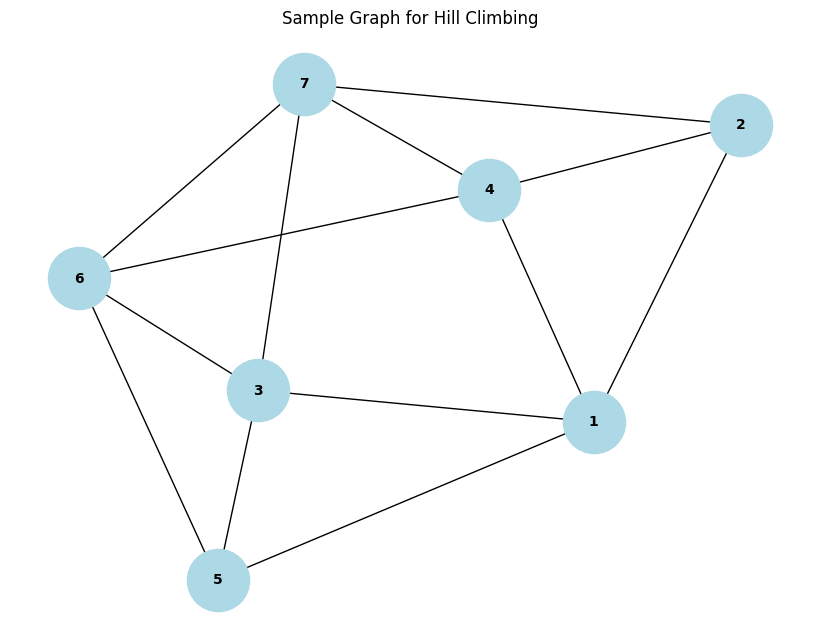

In [23]:
G = nx.Graph()
G.add_edges_from([(1, 2), (1, 3), (1, 4), (1, 5),(2, 4), (3, 5),(3, 6), (3, 7), (4, 6), (5, 6), (6, 7), (7, 4), (7, 2)])
# G = nx.gnp_random_graph(10, 0.33)
plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, font_weight='bold')
plt.title("Sample Graph for Hill Climbing")
plt.show()


Starting Hill Climbing from node: 1
Current node: 1, Heuristic value: 1
  Checking neighbor: 2, Heuristic value: 2
  Checking neighbor: 3, Heuristic value: 3
  Checking neighbor: 4, Heuristic value: 4
  Checking neighbor: 5, Heuristic value: 5
Moved to a better node: 5 (Value: 5)
Current node: 5, Heuristic value: 5
  Checking neighbor: 1, Heuristic value: 1
  Checking neighbor: 3, Heuristic value: 3
  Checking neighbor: 6, Heuristic value: 6
Moved to a better node: 6 (Value: 6)
Current node: 6, Heuristic value: 6
  Checking neighbor: 3, Heuristic value: 3
  Checking neighbor: 4, Heuristic value: 4
  Checking neighbor: 5, Heuristic value: 5
  Checking neighbor: 7, Heuristic value: 7
Moved to a better node: 7 (Value: 7)
Current node: 7, Heuristic value: 7
  Checking neighbor: 3, Heuristic value: 3
  Checking neighbor: 6, Heuristic value: 6
  Checking neighbor: 4, Heuristic value: 4
  Checking neighbor: 2, Heuristic value: 2
No better neighbor found. Local optimum reached at node: 7

Hil

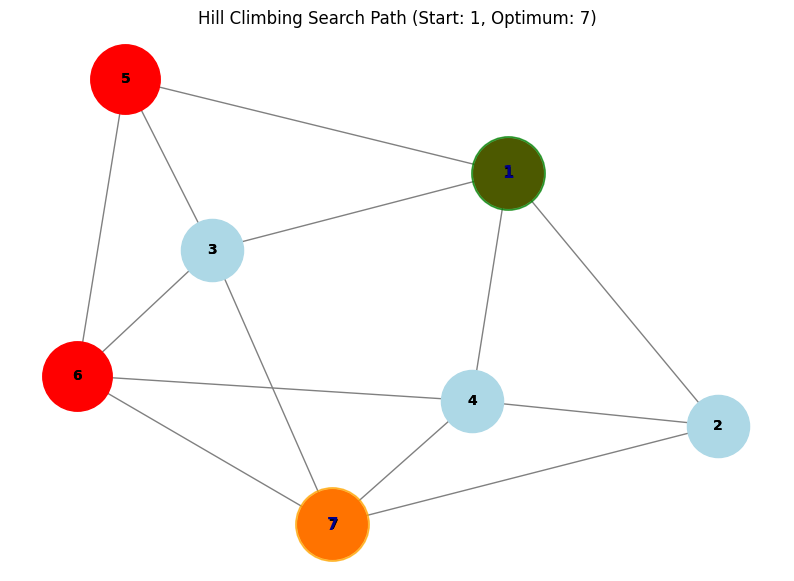

In [24]:
import matplotlib.pyplot as plt
import networkx as nx

# Assuming G is already defined from the previous cell
# If G is not defined, you might need to re-run the graph creation cell
# G = nx.Graph()
# G.add_edges_from([(1, 2), (1, 3), (2, 4), (3, 5), (4, 6), (5, 6), (6, 7)])

def hill_climbing(graph, start_node, heuristic_function):
    """
    Applies the Hill Climbing algorithm to find a local optimum in a graph.

    Args:
        graph (nx.Graph): The networkx graph object.
        start_node: The node from which the search will begin.
        heuristic_function (callable): A function that takes a node and returns its heuristic value.
                                       The algorithm tries to maximize this value.

    Returns:
        tuple: A tuple containing the local optimum node and the path taken.
    """
    current_node = start_node  # Initialize the current node to the starting node
    path = [current_node]     # Keep track of the path taken during the search

    print(f"\nStarting Hill Climbing from node: {start_node}")

    while True:
        # Get the heuristic value of the current node
        current_heuristic_value = heuristic_function(current_node)
        print(f"Current node: {current_node}, Heuristic value: {current_heuristic_value}")

        # Assume the current node is the best neighbor initially
        best_neighbor = current_node
        best_neighbor_heuristic = current_heuristic_value

        # Explore neighbors to find a better state
        # Iterate through all neighbors of the current node
        for neighbor in graph.neighbors(current_node):
            # Calculate the heuristic value for the neighbor
            neighbor_heuristic_value = heuristic_function(neighbor)
            print(f"  Checking neighbor: {neighbor}, Heuristic value: {neighbor_heuristic_value}")

            # If this neighbor has a better heuristic value than the current best neighbor found so far
            if neighbor_heuristic_value > best_neighbor_heuristic:
                best_neighbor = neighbor                 # Update the best neighbor
                best_neighbor_heuristic = neighbor_heuristic_value # Update its heuristic value

        # Check if we found a better neighbor than the current node itself
        if best_neighbor_heuristic > current_heuristic_value:
            current_node = best_neighbor  # Move to the better neighbor
            path.append(current_node)     # Add the new current node to the path
            print(f"Moved to a better node: {current_node} (Value: {best_neighbor_heuristic})")
        else:
            # If no neighbor (or the current node itself) has a better heuristic value,
            # we have reached a local optimum.
            print(f"No better neighbor found. Local optimum reached at node: {current_node}")
            break  # Exit the loop as we can no longer improve

    return current_node, path # Return the local optimum node and the path taken

# --- Define a simple heuristic function for the graph G ---
# For this example, we'll use the node's label (integer value) as its 'heuristic score'.
# The goal of Hill Climbing will be to find the node with the highest label.
def node_label_heuristic(node):
    """
    A simple heuristic function that returns the node's label as its value.
    Assumes node labels are integers.
    """
    return node

# --- Apply Hill Climbing ---
# Choose a starting node for the algorithm.
# Let's start from node 1.
start_node = 1

# Run the Hill Climbing algorithm
local_optimum, search_path = hill_climbing(G, start_node, node_label_heuristic)

print(f"\nHill Climbing finished.")
print(f"Local optimum found: {local_optimum}")
print(f"Path taken: {search_path}")

# --- Visualization of the search path ---
plt.figure(figsize=(10, 7)) # Create a figure with a specific size for the plot

# Define the layout for the graph visualization. spring_layout is a common choice.
pos = nx.spring_layout(G)

# Draw all nodes in the graph in a lightblue color
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000)
# Draw all edges in the graph in a grey color
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1)
# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Highlight the nodes in the search path
# Nodes in the path will be colored red
nx.draw_networkx_nodes(G, pos, nodelist=search_path, node_color='red', node_size=2500)
# Draw labels again to ensure they are visible over highlighted nodes
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='black')

# Highlight the starting node in green
nx.draw_networkx_nodes(G, pos, nodelist=[start_node], node_color='green', node_size=2800, alpha=0.7)
# Highlight the local optimum node in orange
nx.draw_networkx_nodes(G, pos, nodelist=[local_optimum], node_color='orange', node_size=2800, alpha=0.7)

# Draw labels for start and optimum nodes explicitly to ensure they are on top
nx.draw_networkx_labels(G, pos, labels={start_node: start_node, local_optimum: local_optimum}, font_size=12, font_color='darkblue', font_weight='heavy')

plt.title(f"Hill Climbing Search Path (Start: {start_node}, Optimum: {local_optimum})") # Set the title of the plot
plt.axis('off') # Turn off the axis for a cleaner graph visualization
plt.show() # Display the plot

### **Q&A: Understanding the Hill Climbing Implementation**

1. **What is the Hill Climbing algorithm?**
   - It is a local search algorithm that continuously moves in the direction of increasing value (uphill) to find the best state or 'peak'.

2. **What are the parameters of the `hill_climbing` function?**
   - `graph`: The NetworkX graph object being searched.
   - `start_node`: The node where the algorithm begins.
   - `heuristic_function`: The rule used to assign a value to each node.

3. **What are the return values of the `hill_climbing` function?**
   - A `tuple` containing the **local optimum node** (the peak found) and the **path taken** (the list of nodes visited).

4. **Does this code use any hyperparameters?**
   - In this specific simple implementation, there are no classic hyperparameters (like learning rate), but the **choice of starting node** and the **specific heuristic function** act as configurable settings that affect the outcome.

5. **What is a 'Heuristic' in this code?**
   - It is a function (`node_label_heuristic`) that estimates how 'good' a node is. Here, we simply used the node's number (label) as its value.

6. **What library is used to create the graph structure?**
   - `networkx` (imported as `nx`).

7. **What library is used to draw the graph?**
   - `matplotlib.pyplot` (imported as `plt`).

8. **What does `graph.neighbors(current_node)` do?**
   - It returns all nodes directly connected to the `current_node` by an edge.

9. **What is a 'Local Optimum'?**
   - A state where no neighbor has a higher value than the current state, even if a higher peak exists elsewhere in the graph.

10. **Why does the algorithm use a `while True` loop?**
    - To keep moving to better neighbors until it can no longer find one that is higher.

11. **How is the path tracked in the code?**
    - Using a list called `path` that appends each new `current_node` whenever a move is made.

12. **What does `nx.spring_layout(G)` do?**
    - It calculates positions for nodes using a force-directed algorithm to make the graph look organized and readable.

13. **What is the purpose of `with_labels=True`?**
    - It ensures that the node numbers (1, 2, 3...) are printed inside the nodes on the plot.

14. **How do we identify the 'Best Neighbor'?**
    - The code compares the heuristic value of every neighbor and picks the one with the maximum value.

15. **What happens if all neighbors have lower values than the current node?**
    - The algorithm stops, prints that a local optimum is reached, and breaks the loop.

16. **In the visualization, what does the color Red represent?**
    - The nodes that were part of the `search_path` taken by the algorithm.

17. **What does the color Green represent in the final plot?**
    - The `start_node` (where the search began).

18. **What does the color Orange represent in the final plot?**
    - The `local_optimum` (the final destination/highest point reached).

19. **Can Hill Climbing get stuck?**
    - Yes, it can get stuck in 'local maxima', which are peaks that are not the highest overall point in the entire graph.

20. **How can you change the goal of the algorithm?**
    - By modifying the `heuristic_function` to return different values (e.g., node degrees or custom weights).